### **Telco Customer Churn Prediction - Data Preparation**

**Objective:** To develop a machine learning classification model that predicts customers who are likely to discontinue their telecom subscription services. The project aims to identify the key factors influencing customer churn through data cleaning, feature engineering, model training, and evaluation, enabling telecom companies to implement targeted customer retention strategies and reduce revenue loss.

**Notebook Objective:** In this notebook we perform a thorough Exploratory Data Analysis (EDA) on the cleaned dataset we created in `01_data_preparation.ipynb`.

**Core objective:** Understand the data deeply, uncover patterns, relationships, and key drivers of churn so that we can:

+ Build strong intuition about what actually predicts churn
+ Identify the most promising features (and potential new ones) for modeling
+ Spot data quality issues, outliers, or missing value patterns that could affect model performance
+ Generate business-relevant insights that we can immediately translate into retention recommendations

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
plt.style.use('seaborn-v0_8-bright')
sns.set_palette("muted")
%matplotlib inline

**Load and Inspect Data**

In [2]:
data = pd.read_csv("C:\\Users\\KOLADE\\OneDrive\\Documents\\AkoladeDSJourney\\Telco-Customer-Churn-Prediction\\data\\processed\\telco_customer_churn_cleaned.csv")
df = data.copy()

print(f"Data shape: {df.shape}") # check the shape of the dataset
print(f"Data types:\n{df.dtypes}") # check the data types of the columns

Data shape: (7043, 21)
Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f"Number of duplicate rows: {df.duplicated().sum()}") # check for duplicates
print(f"Number of missing values: {df.isnull().sum().sum()}") # check for missing values

df["customerID"].nunique() # check for unique customer IDs

Number of duplicate rows: 0
Number of missing values: 0


7043

- No Missing data
- No Duplicates records
- `customerID` are unique - no duplicates

#### Univariate Analysis
- Understand each variable individually

**Target Variable**

In [5]:
df.rename(columns={'Churn': 'Churn_Status'}, inplace=True) # rename column for consistency
df['Churn'] = df['Churn_Status'].map({'Yes': 1, 'No': 0}) # create a new column for churn status

In [6]:
print(df['Churn_Status'].value_counts(dropna=False))
print(f"\nChurn rate: {df['Churn'].mean():.2%}") # calculate churn rate

Churn_Status
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


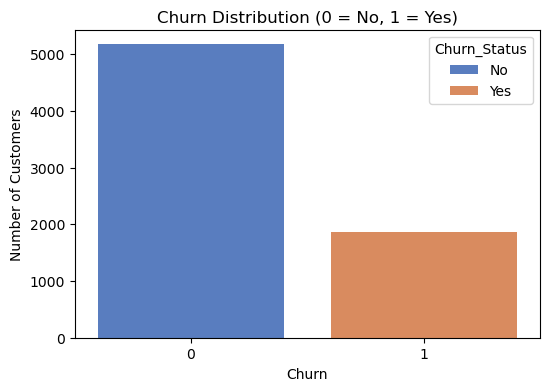

Insight: Class imbalance level → moderate


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn_Status')
plt.title('Churn Distribution (0 = No, 1 = Yes)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

print("Insight: Class imbalance level →", "severe" if df['Churn'].mean() < 0.15 else "moderate" if df['Churn'].mean() < 0.3 else "balanced")

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Status,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


**Categorical Features**

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID') # remove customerID from categorical columns
categorical_cols.remove('Churn_Status') # remove Churn_Status from categorical columns
categorical_cols = categorical_cols + ['SeniorCitizen'] # add SeniorCitizen to categorical columns
print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


In [10]:
df[categorical_cols].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0


Distribution of gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64
Unique values in gender: 2
Missing values in gender: 0


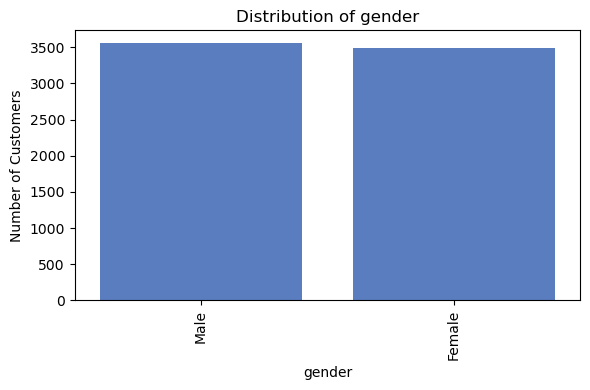

Most common value in gender: Male with count: 3555 (50.48%)


Distribution of Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Unique values in Partner: 2
Missing values in Partner: 0


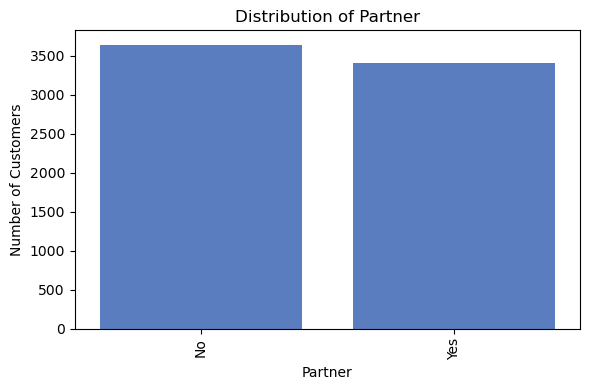

Most common value in Partner: No with count: 3641 (51.70%)


Distribution of Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Unique values in Dependents: 2
Missing values in Dependents: 0


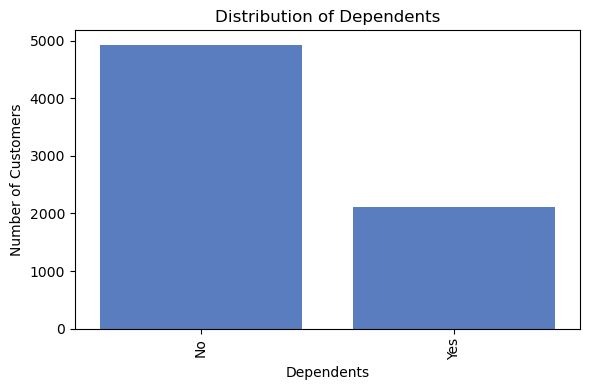

Most common value in Dependents: No with count: 4933 (70.04%)


Distribution of PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
Unique values in PhoneService: 2
Missing values in PhoneService: 0


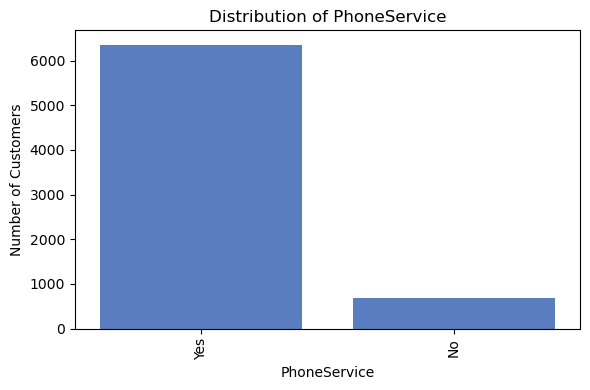

Most common value in PhoneService: Yes with count: 6361 (90.32%)


Distribution of MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
Unique values in MultipleLines: 3
Missing values in MultipleLines: 0


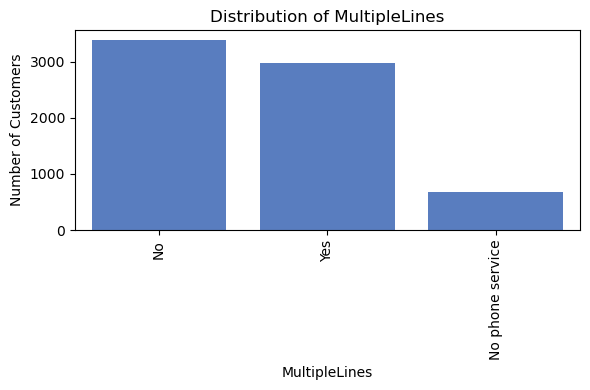

Most common value in MultipleLines: No with count: 3390 (48.13%)


Distribution of InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Unique values in InternetService: 3
Missing values in InternetService: 0


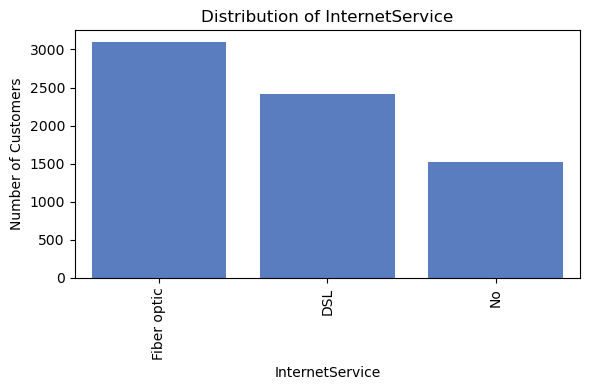

Most common value in InternetService: Fiber optic with count: 3096 (43.96%)


Distribution of OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
Unique values in OnlineSecurity: 3
Missing values in OnlineSecurity: 0


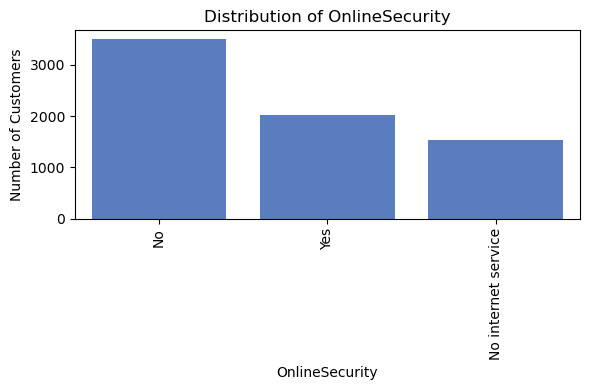

Most common value in OnlineSecurity: No with count: 3498 (49.67%)


Distribution of OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
Unique values in OnlineBackup: 3
Missing values in OnlineBackup: 0


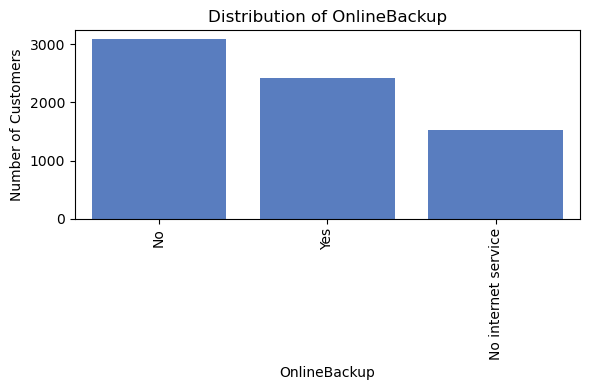

Most common value in OnlineBackup: No with count: 3088 (43.84%)


Distribution of DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
Unique values in DeviceProtection: 3
Missing values in DeviceProtection: 0


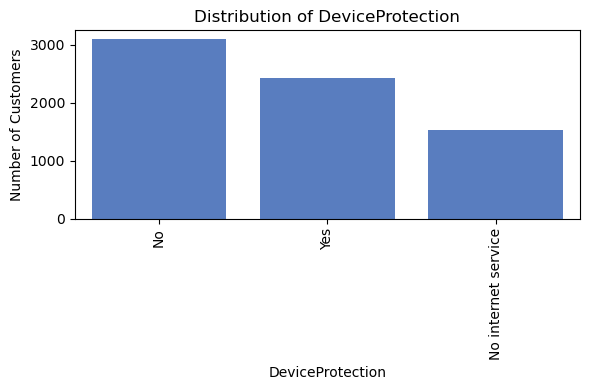

Most common value in DeviceProtection: No with count: 3095 (43.94%)


Distribution of TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
Unique values in TechSupport: 3
Missing values in TechSupport: 0


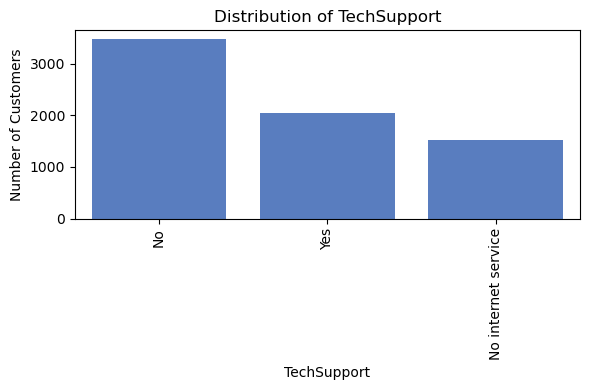

Most common value in TechSupport: No with count: 3473 (49.31%)


Distribution of StreamingTV:
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
Unique values in StreamingTV: 3
Missing values in StreamingTV: 0


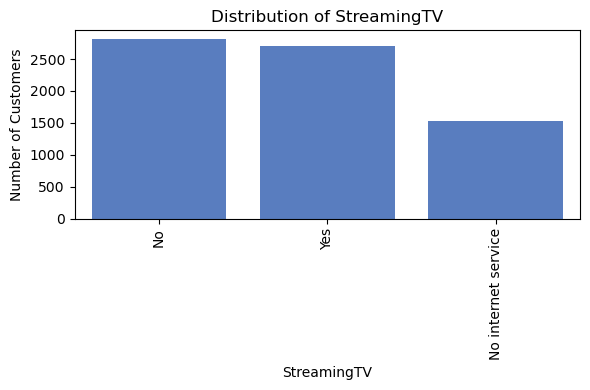

Most common value in StreamingTV: No with count: 2810 (39.90%)


Distribution of StreamingMovies:
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64
Unique values in StreamingMovies: 3
Missing values in StreamingMovies: 0


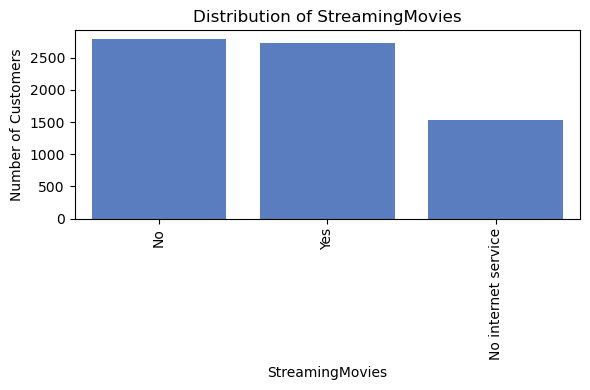

Most common value in StreamingMovies: No with count: 2785 (39.54%)


Distribution of Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Unique values in Contract: 3
Missing values in Contract: 0


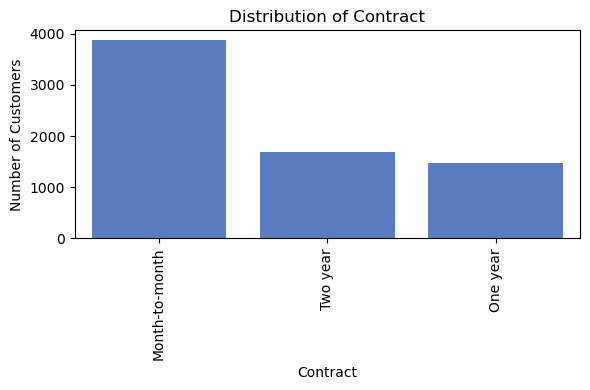

Most common value in Contract: Month-to-month with count: 3875 (55.02%)


Distribution of PaperlessBilling:
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64
Unique values in PaperlessBilling: 2
Missing values in PaperlessBilling: 0


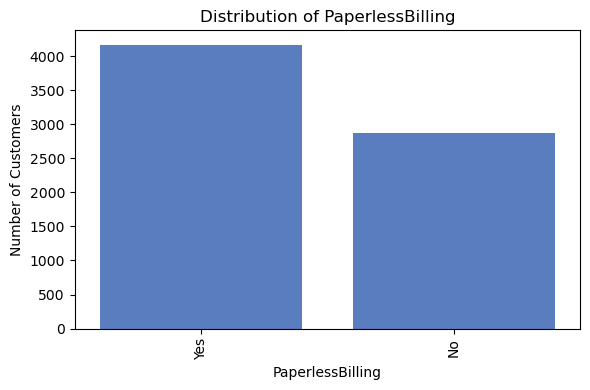

Most common value in PaperlessBilling: Yes with count: 4171 (59.22%)


Distribution of PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
Unique values in PaymentMethod: 4
Missing values in PaymentMethod: 0


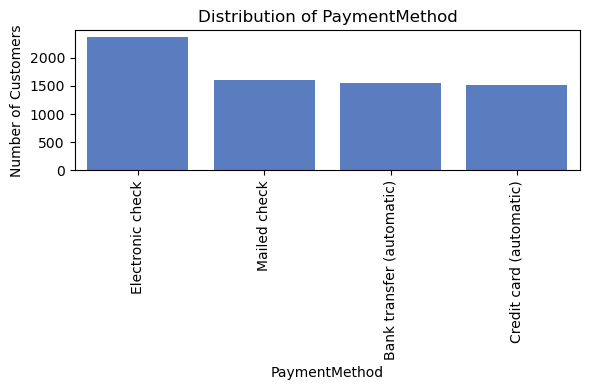

Most common value in PaymentMethod: Electronic check with count: 2365 (33.58%)


Distribution of SeniorCitizen:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Unique values in SeniorCitizen: 2
Missing values in SeniorCitizen: 0


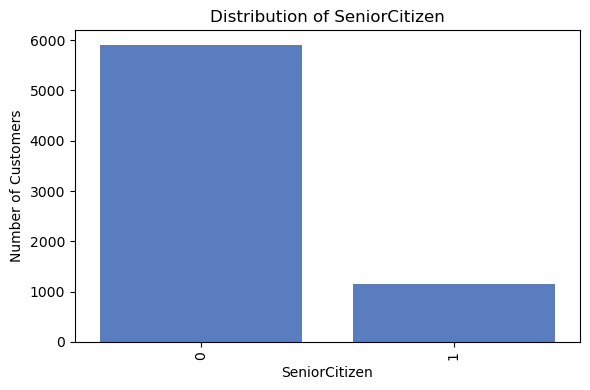

Most common value in SeniorCitizen: 0 with count: 5901 (83.79%)




In [11]:
for col in categorical_cols:
    print(f"{"=" * 50}\nDistribution of {col}:\n{df[col].value_counts(dropna=False)}")
    print(f"Unique values in {col}: {df[col].nunique()}")
    print(f"Missing values in {col}: {df[col].isnull().sum()}")

    if df[col].nunique() > 10:
        print(f"Note: {col} has more than 10 unique values, consider grouping or encoding for modeling.\n")
        plt.figure(figsize=(10, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Number of Customers')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Number of Customers')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    print(f"Most common value in {col}: {df[col].mode()[0]} with count: {df[col].value_counts().max()} ({df[col].value_counts().max() / len(df) * 100:.2f}%)")
    print("\n") # add space between outputs

**Numerical Features**

In [12]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('Churn') # remove Churn from numeric columns
numeric_cols.remove('SeniorCitizen') # remove SeniorCitizen from numeric columns
numeric_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [13]:
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [14]:
df[numeric_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


Summary statistics for tenure:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness of tenure: 0.24
Kurtosis of tenure: -1.39
Missing values in tenure: 0


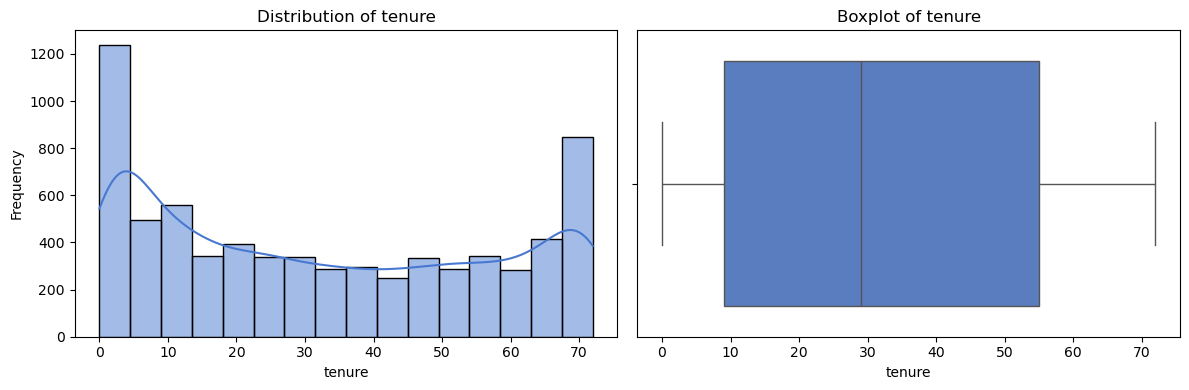

Quick notes:
• Skewness direction → roughly symmetric
• Extreme values? → No major extremes
• Business intuition → Moderate variation


Summary statistics for MonthlyCharges:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Skewness of MonthlyCharges: -0.22
Kurtosis of MonthlyCharges: -1.26
Missing values in MonthlyCharges: 0


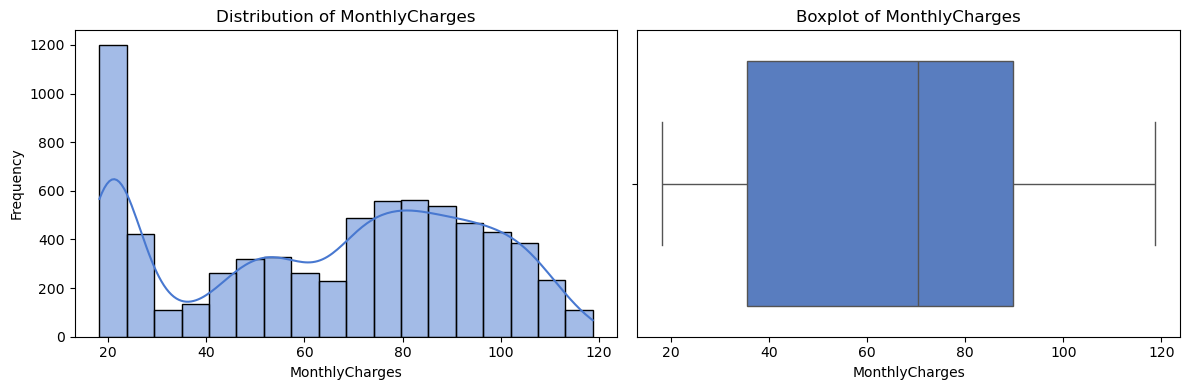

Quick notes:
• Skewness direction → roughly symmetric
• Extreme values? → No major extremes
• Business intuition → Moderate variation


Summary statistics for TotalCharges:
count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64
Skewness of TotalCharges: 0.96
Kurtosis of TotalCharges: -0.23
Missing values in TotalCharges: 0


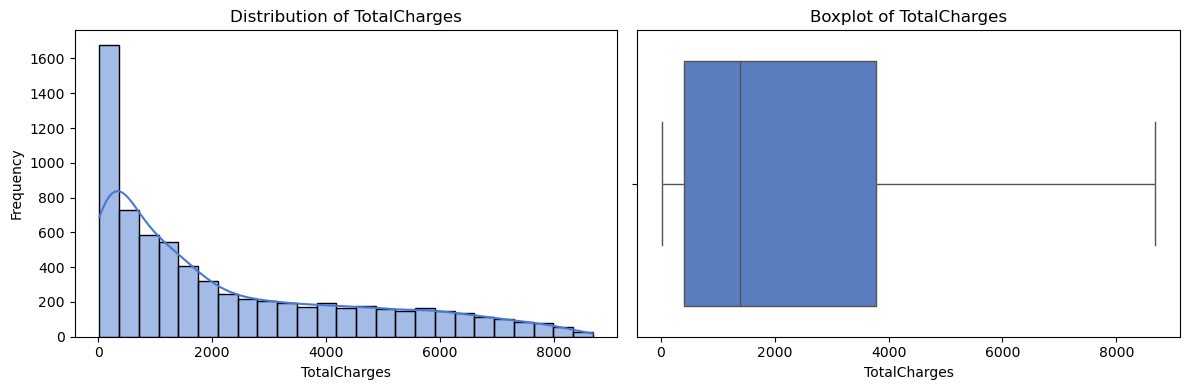

Quick notes:
• Skewness direction → right-skewed (positive)
• Extreme values? → No major extremes
• Business intuition → Moderate variation




In [15]:
for col in numeric_cols:
    print(f"{"=" * 50}\nSummary statistics for {col}:\n{df[col].describe()}")
    print(f"Skewness of {col}: {df[col].skew():.2f}")
    print(f"Kurtosis of {col}: {df[col].kurtosis():.2f}")
    print(f"Missing values in {col}: {df[col].isnull().sum()}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution plot with KDE
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Boxplot for outlier detection
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

    # Quick interpretation
    print("Quick notes:")
    print("• Skewness direction →", "right-skewed (positive)" if df[col].skew() > 0.5 else "left-skewed" if df[col].skew() < -0.5 else "roughly symmetric")
    print("• Extreme values? →", "Yes – investigate" if df[col].max() > df[col].quantile(0.99)*3 else "No major extremes")
    print("• Business intuition →", "High variance likely → strong predictor candidate" if df[col].std() / df[col].mean() > 1 else "Moderate variation")
    print("\n")

#### Bivariate Analysis

Understanding relationships between features and the target variable (Churn) is crucial for feature selection and engineering. We will analyze how each feature relates to churn status, which can provide insights into potential drivers of customer attrition.

In [16]:
# helper function to check relationship between categorical features and churn
def churn_rate_by_cat(df, col):
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    crosstab.columns = ['Active (%)', 'Churned (%)']
    print(f"\nChurn Rate by {col}:\n", crosstab.round(2))
    crosstab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap='Set2')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel('% of Customers')
    plt.show()

    # Quick note
    print("Quick notes:")
    print("• Strong signal? →", "Yes" if crosstab['Churned (%)'].max() - crosstab['Churned (%)'].min() > 20 else "Moderate/No")
    print("\n")

Analyzing churn rate by gender...

Churn Rate by gender:
         Active (%)  Churned (%)
gender                         
Female       73.08        26.92
Male         73.84        26.16


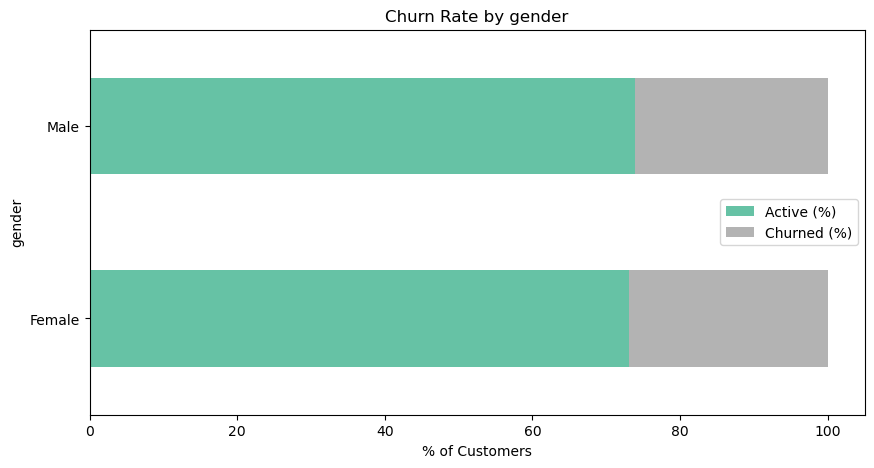

Quick notes:
• Strong signal? → Moderate/No


Analyzing churn rate by Partner...

Churn Rate by Partner:
          Active (%)  Churned (%)
Partner                         
No            67.04        32.96
Yes           80.34        19.66


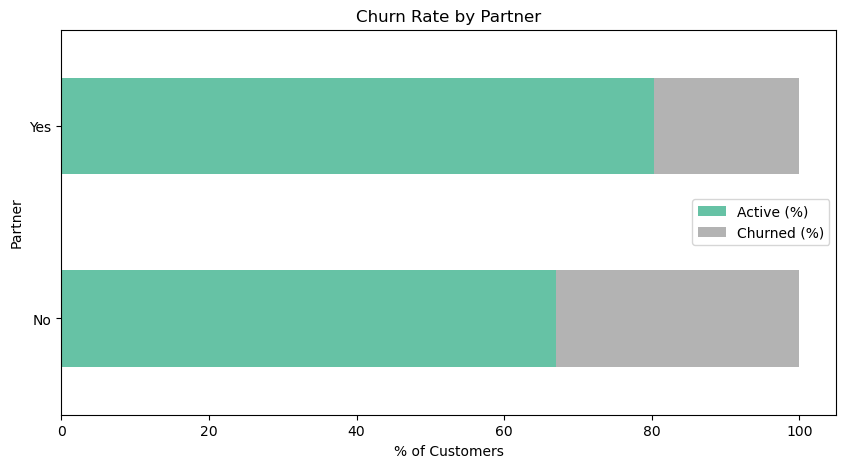

Quick notes:
• Strong signal? → Moderate/No


Analyzing churn rate by Dependents...

Churn Rate by Dependents:
             Active (%)  Churned (%)
Dependents                         
No               68.72        31.28
Yes              84.55        15.45


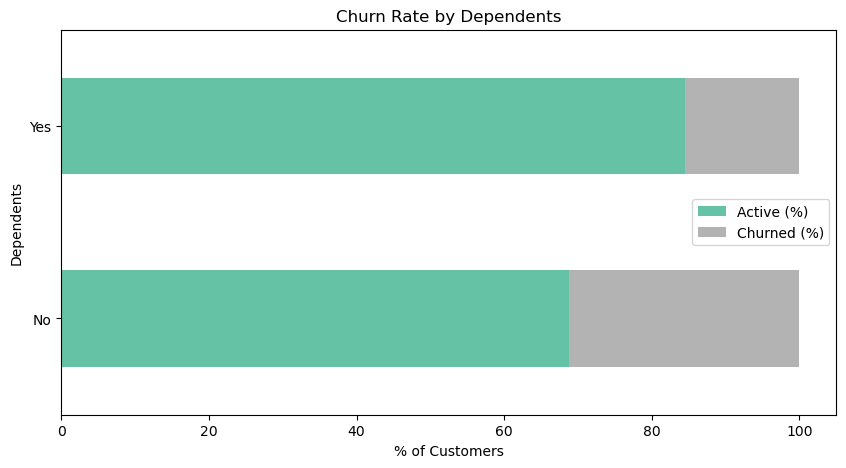

Quick notes:
• Strong signal? → Moderate/No


Analyzing churn rate by PhoneService...

Churn Rate by PhoneService:
               Active (%)  Churned (%)
PhoneService                         
No                 75.07        24.93
Yes                73.29        26.71


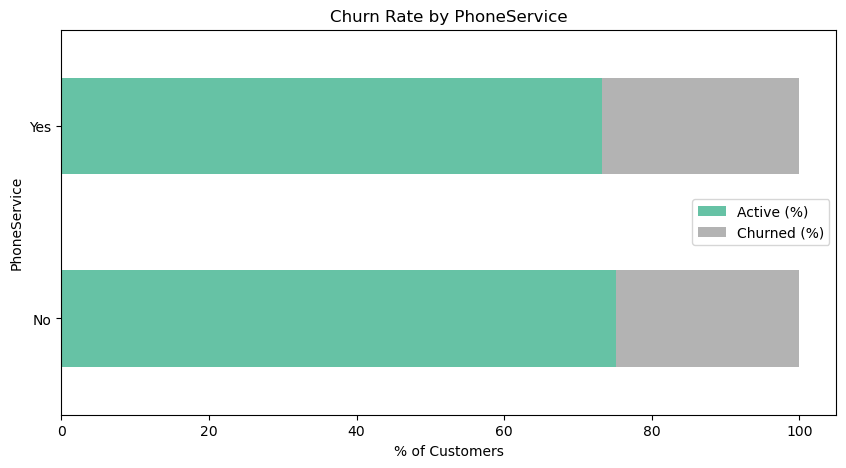

Quick notes:
• Strong signal? → Moderate/No


Analyzing churn rate by MultipleLines...

Churn Rate by MultipleLines:
                   Active (%)  Churned (%)
MultipleLines                            
No                     74.96        25.04
No phone service       75.07        24.93
Yes                    71.39        28.61


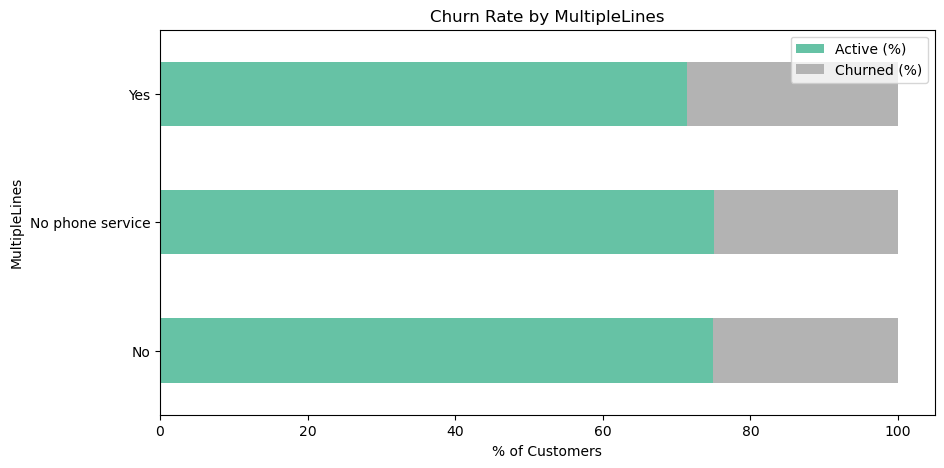

Quick notes:
• Strong signal? → Moderate/No


Analyzing churn rate by InternetService...

Churn Rate by InternetService:
                  Active (%)  Churned (%)
InternetService                         
DSL                   81.04        18.96
Fiber optic           58.11        41.89
No                    92.60         7.40


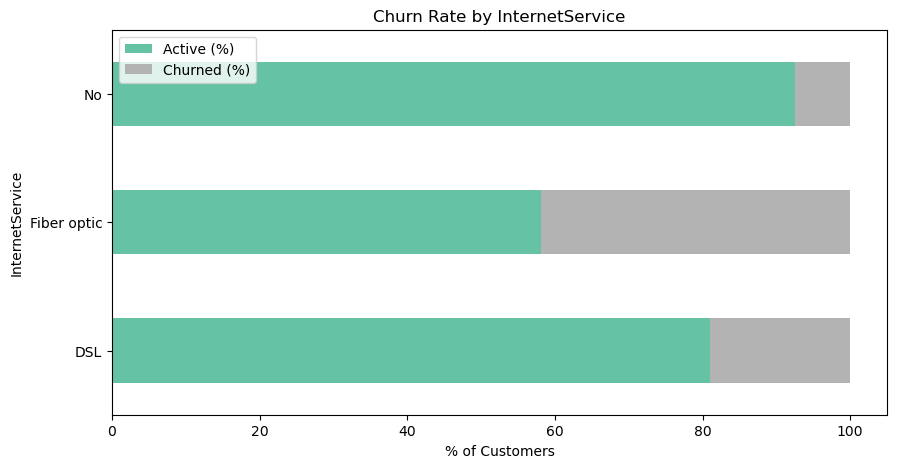

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by OnlineSecurity...

Churn Rate by OnlineSecurity:
                      Active (%)  Churned (%)
OnlineSecurity                              
No                        58.23        41.77
No internet service       92.60         7.40
Yes                       85.39        14.61


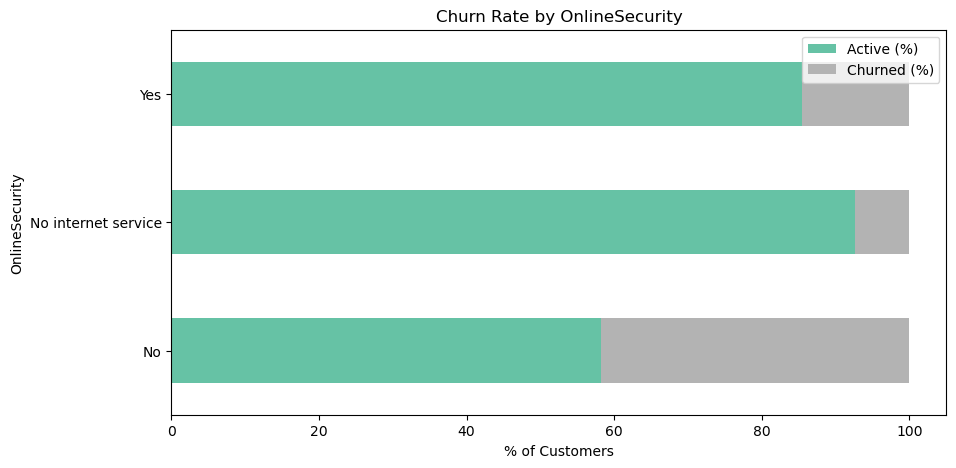

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by OnlineBackup...

Churn Rate by OnlineBackup:
                      Active (%)  Churned (%)
OnlineBackup                                
No                        60.07        39.93
No internet service       92.60         7.40
Yes                       78.47        21.53


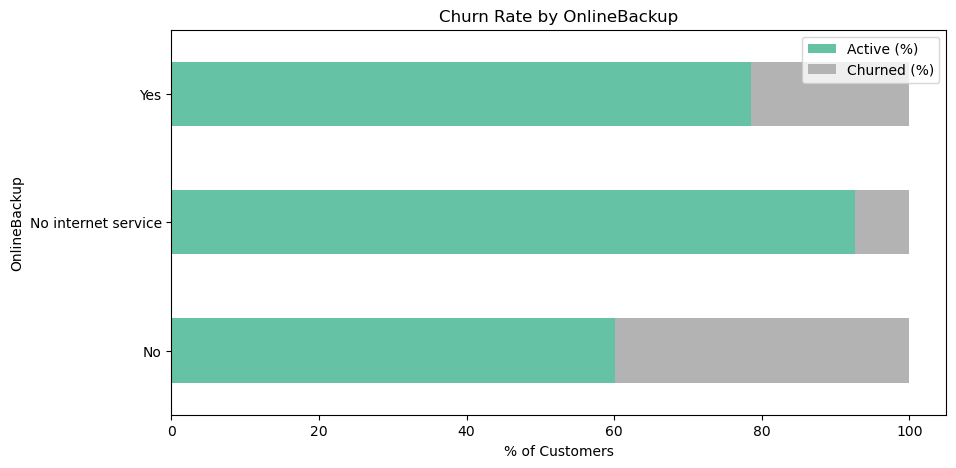

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by DeviceProtection...

Churn Rate by DeviceProtection:
                      Active (%)  Churned (%)
DeviceProtection                            
No                        60.87        39.13
No internet service       92.60         7.40
Yes                       77.50        22.50


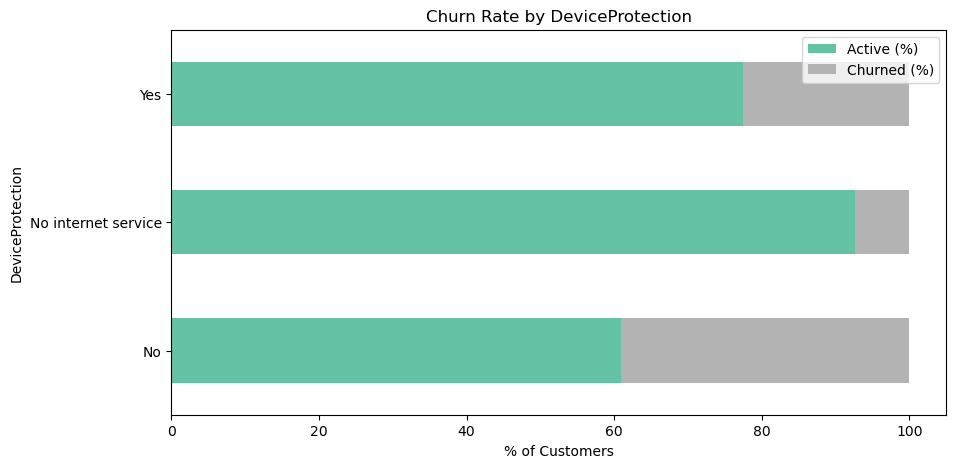

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by TechSupport...

Churn Rate by TechSupport:
                      Active (%)  Churned (%)
TechSupport                                 
No                        58.36        41.64
No internet service       92.60         7.40
Yes                       84.83        15.17


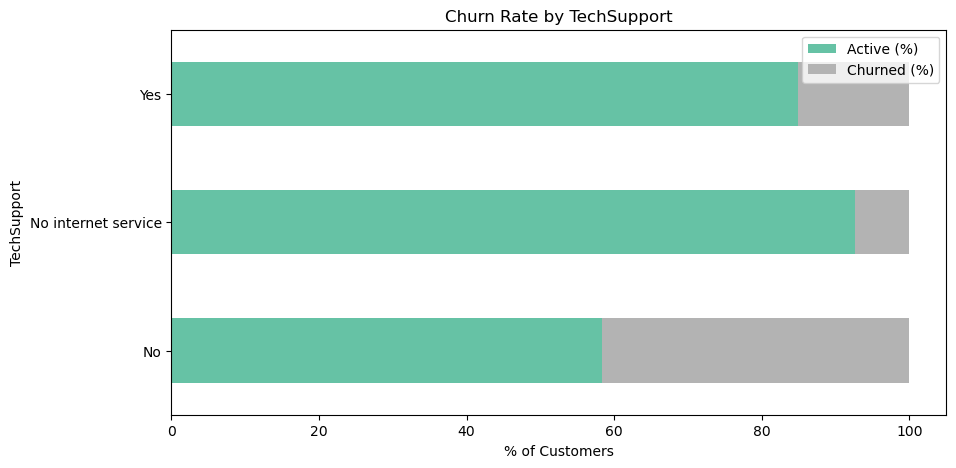

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by StreamingTV...

Churn Rate by StreamingTV:
                      Active (%)  Churned (%)
StreamingTV                                 
No                        66.48        33.52
No internet service       92.60         7.40
Yes                       69.93        30.07


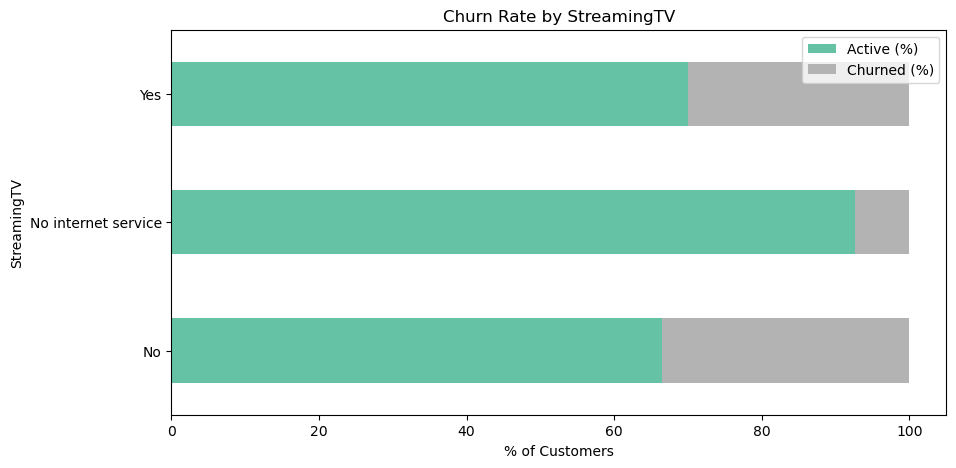

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by StreamingMovies...

Churn Rate by StreamingMovies:
                      Active (%)  Churned (%)
StreamingMovies                             
No                        66.32        33.68
No internet service       92.60         7.40
Yes                       70.06        29.94


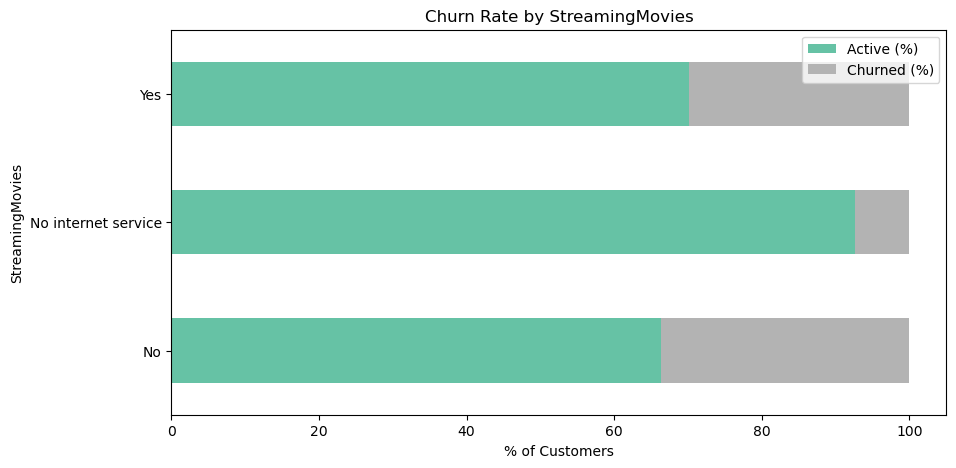

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by Contract...

Churn Rate by Contract:
                 Active (%)  Churned (%)
Contract                               
Month-to-month       57.29        42.71
One year             88.73        11.27
Two year             97.17         2.83


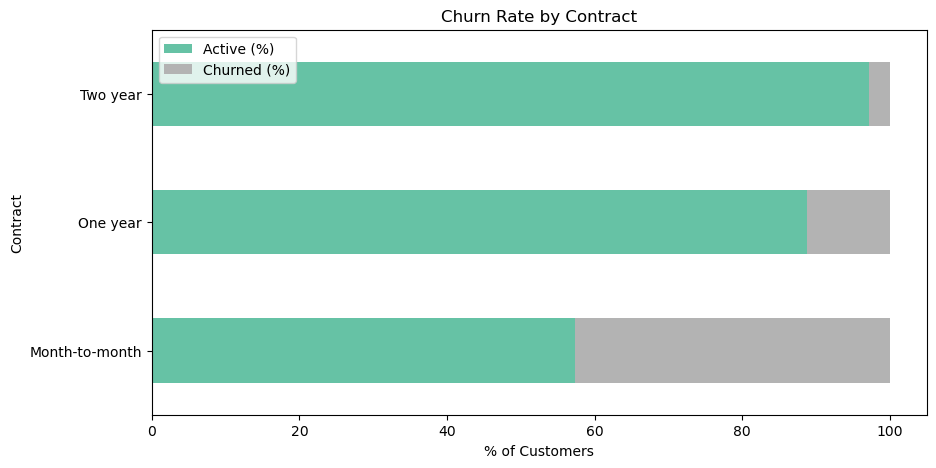

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by PaperlessBilling...

Churn Rate by PaperlessBilling:
                   Active (%)  Churned (%)
PaperlessBilling                         
No                     83.67        16.33
Yes                    66.43        33.57


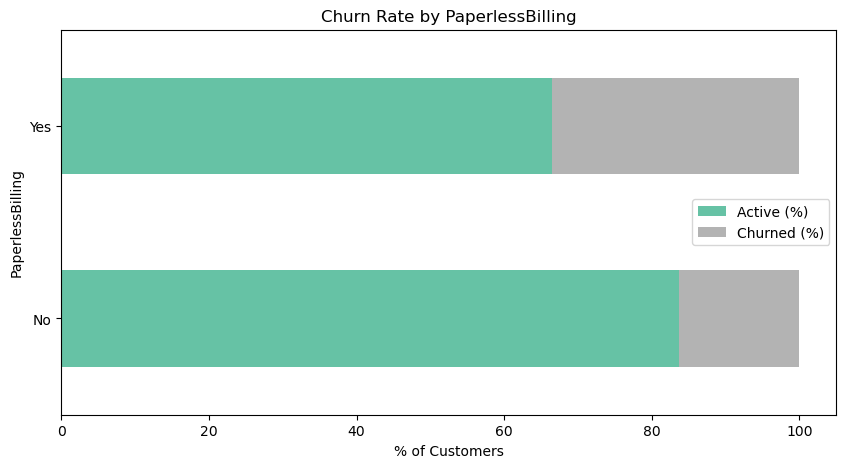

Quick notes:
• Strong signal? → Moderate/No


Analyzing churn rate by PaymentMethod...

Churn Rate by PaymentMethod:
                            Active (%)  Churned (%)
PaymentMethod                                     
Bank transfer (automatic)       83.29        16.71
Credit card (automatic)         84.76        15.24
Electronic check                54.71        45.29
Mailed check                    80.89        19.11


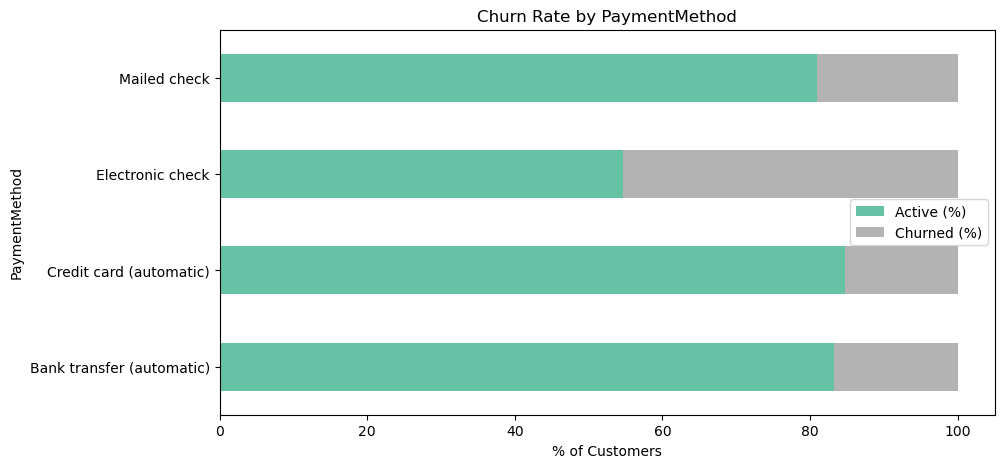

Quick notes:
• Strong signal? → Yes


Analyzing churn rate by SeniorCitizen...

Churn Rate by SeniorCitizen:
                Active (%)  Churned (%)
SeniorCitizen                         
0                   76.39        23.61
1                   58.32        41.68


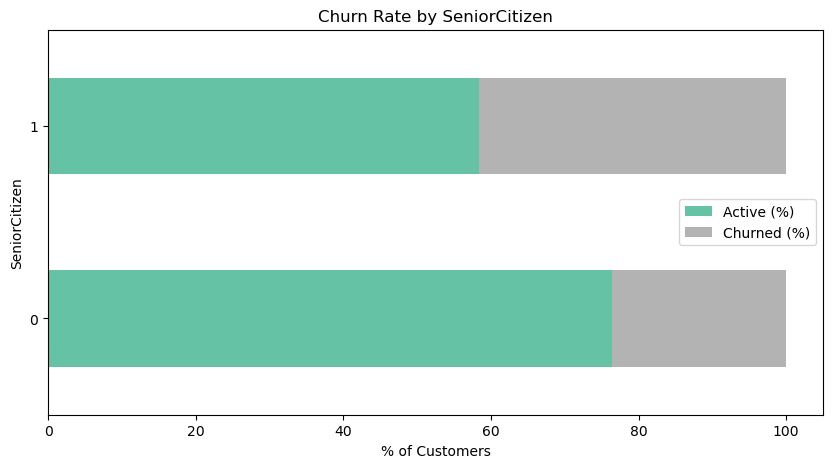

Quick notes:
• Strong signal? → Moderate/No




In [17]:
for col in categorical_cols:
    print(f"{"=" * 50}\nAnalyzing churn rate by {col}...")
    churn_rate_by_cat(df, col)

In [18]:
# Helper for numeric vs churn
def numeric_vs_churn(df, col):
    print(f"\n{col} stats by Churn:\n", df.groupby('Churn')[col].describe().round(2))
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Churn', y=col, palette='Set3', hue='Churn')
    plt.title(f'{col} by Churn (0=Active, 1=Churned)')
    plt.show()

    # Quick note
    means = df.groupby('Churn')[col].mean()
    print("• Mean difference (Churned - Active):", round(means[1] - means[0], 2))
    print("• Potential predictor? →", "Yes" if abs(means[1] - means[0]) / means[0] > 0.2 else "Weak")


Bivariate: tenure vs Churn

tenure stats by Churn:
         count   mean    std  min   25%   50%   75%   max
Churn                                                   
0      5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
1      1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


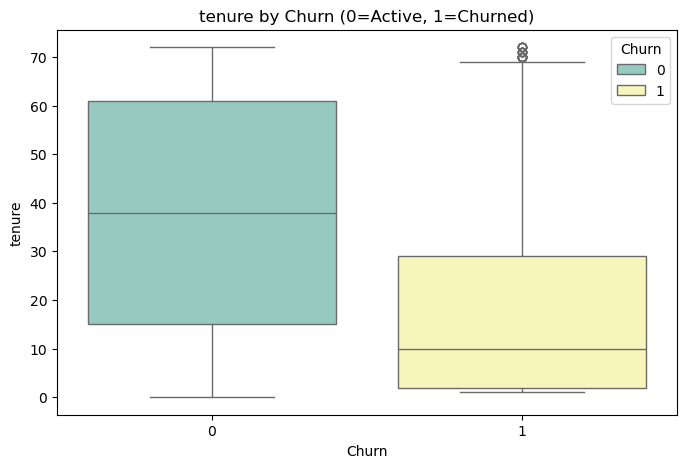

• Mean difference (Churned - Active): -19.59
• Potential predictor? → Yes

Bivariate: MonthlyCharges vs Churn

MonthlyCharges stats by Churn:
         count   mean    std    min    25%    50%   75%     max
Churn                                                         
0      5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
1      1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


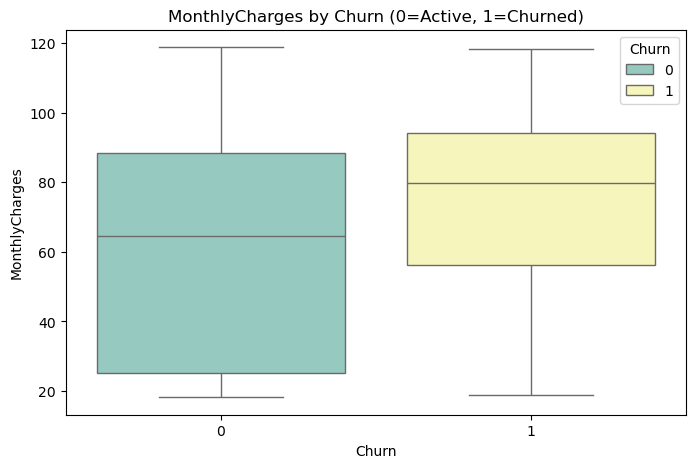

• Mean difference (Churned - Active): 13.18
• Potential predictor? → Yes

Bivariate: TotalCharges vs Churn

TotalCharges stats by Churn:
         count     mean      std    min     25%      50%      75%      max
Churn                                                                    
0      5174.0  2552.88  2327.59  18.80  579.58  1679.52  4262.85  8672.45
1      1869.0  1531.80  1890.82  18.85  134.50   703.55  2331.30  8684.80


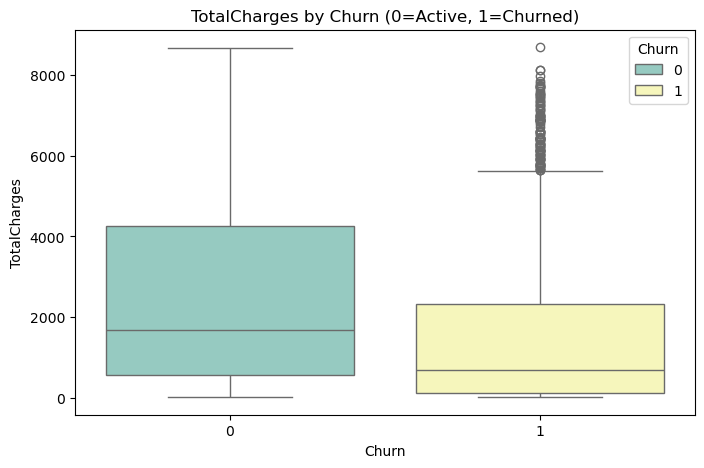

• Mean difference (Churned - Active): -1021.09
• Potential predictor? → Yes


In [19]:
for col in numeric_cols:
    print(f"\n{'='*50}\nBivariate: {col} vs Churn")
    numeric_vs_churn(df, col)

**Correleration Heatmap**

In [20]:
num_features = numeric_cols + ['Churn']
print(num_features)

['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


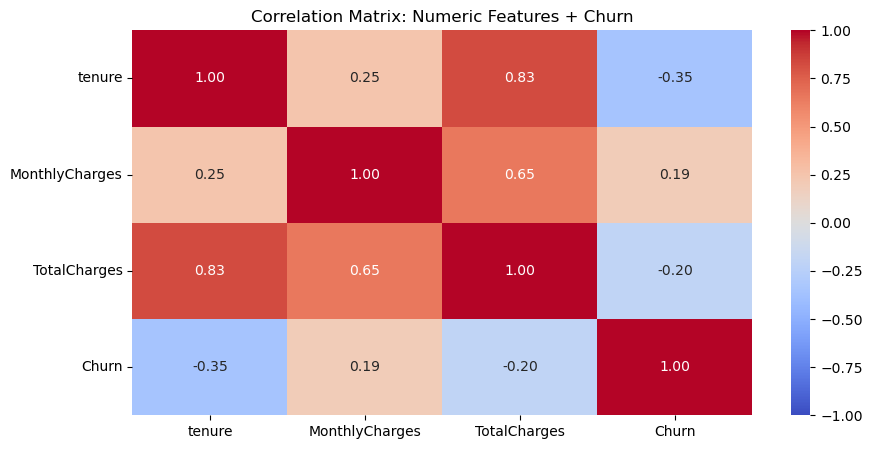

In [21]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_features].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f'
)
plt.title('Correlation Matrix: Numeric Features + Churn')
plt.show()

<Figure size 1000x500 with 0 Axes>

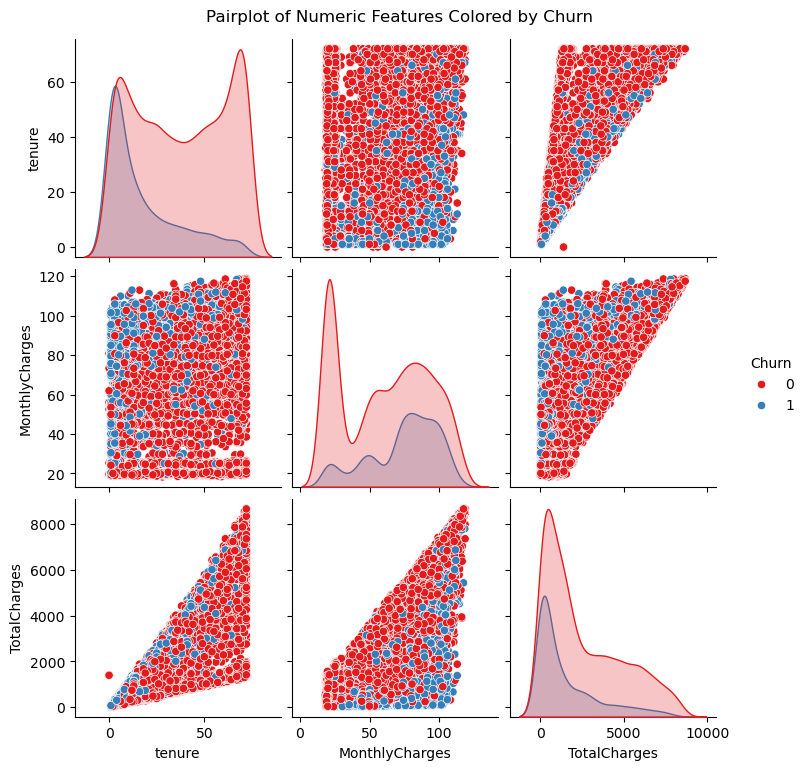

In [22]:
plt.figure(figsize=(10, 5))
sns.pairplot(df[num_features], hue='Churn', palette='Set1')
plt.suptitle('Pairplot of Numeric Features Colored by Churn', y=1.02)
plt.show()